# Speculative Decoding from Scratch — Solution

Build order:
1. **Stage 1** — Baseline greedy decoding (no `model.generate()`)
2. **Stage 2** — Core speculative decoding loop
3. **Stage 3** — Metrics & correctness verification
4. **Stage 4** — Code edit workload adaptation

## Setup

In [1]:
!pip install transformers torch --quiet


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import torch
import torch.nn.functional as F
import time
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Optional
from transformers import AutoTokenizer, AutoModelForCausalLM

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [3]:
DRAFT_MODEL_NAME = "gpt2"
TARGET_MODEL_NAME = "gpt2-xl"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(TARGET_MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

print("Loading draft model...")
draft_model = AutoModelForCausalLM.from_pretrained(DRAFT_MODEL_NAME).to(device).eval()

print("Loading target model...")
target_model = AutoModelForCausalLM.from_pretrained(TARGET_MODEL_NAME).to(device).eval()

print(f"Draft params:  {sum(p.numel() for p in draft_model.parameters()):,}")
print(f"Target params: {sum(p.numel() for p in target_model.parameters()):,}")

Loading tokenizer...
Loading draft model...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading target model...


Loading weights:   0%|          | 0/580 [00:00<?, ?it/s]

Draft params:  124,439,808
Target params: 1,557,611,200


---
## Stage 1 — Baseline Autoregressive Decoding

In [4]:
def greedy_decode(
    model,
    input_ids: torch.Tensor,
    max_new_tokens: int = 50,
) -> tuple[torch.Tensor, float]:
    """
    Greedy autoregressive decoding with KV cache.
    Returns (output_ids, tokens_per_second).
    """
    generated = input_ids.clone()
    past_key_values = None
    t0 = time.time()

    with torch.no_grad():
        for _ in range(max_new_tokens):
            # On first pass feed full sequence; after that feed only last token
            model_input = generated if past_key_values is None else generated[:, -1:]

            outputs = model(
                model_input,
                past_key_values=past_key_values,
                use_cache=True,
            )
            past_key_values = outputs.past_key_values

            # logits: [1, seq_len, vocab] — only last position matters
            next_token = outputs.logits[:, -1, :].argmax(dim=-1, keepdim=True)  # [1, 1]
            generated = torch.cat([generated, next_token], dim=-1)

    elapsed = time.time() - t0
    tps = max_new_tokens / elapsed
    return generated, tps

In [5]:
prompt = "The capital of France is"
input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

output_ids, tps = greedy_decode(draft_model, input_ids, max_new_tokens=20)
print(tokenizer.decode(output_ids[0]))
print(f"Draft model: {tps:.1f} tok/s")

output_ids, tps = greedy_decode(target_model, input_ids, max_new_tokens=20)
print(tokenizer.decode(output_ids[0]))
print(f"Target model: {tps:.1f} tok/s")

The capital of France is the capital of the French Republic, and the capital of the French Republic is the capital of the French
Draft model: 41.6 tok/s
The capital of France is the city of Paris. It is the capital of France and the largest city in France. It is
Target model: 26.3 tok/s


---
## Stage 2 — Speculative Decoding

### 2a — Draft: generate k tokens autoregressively

In [6]:
def draft_autoregressive(
    draft_model,
    input_ids: torch.Tensor,   # [1, seq_len]
    k: int,
    temperature: float = 0.0,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Run draft model autoregressively to produce k candidate tokens.

    Args:
      temperature: 0.0 for greedy (argmax), > 0 for sampling.

    Returns:
      draft_tokens: [k]        integer token ids
      draft_probs:  [k, vocab] probability distribution at each step

    We save the full softmax distribution (not just argmax) because
    the rejection step needs p_draft(xᵢ) for each accepted token.
    """
    draft_tokens = []
    draft_probs = []
    past_key_values = None
    current_ids = input_ids.clone()

    with torch.no_grad():
        for _ in range(k):
            model_input = current_ids if past_key_values is None else current_ids[:, -1:]

            outputs = draft_model(
                model_input,
                past_key_values=past_key_values,
                use_cache=True,
            )
            past_key_values = outputs.past_key_values

            logits = outputs.logits[:, -1, :]        # [1, vocab]

            if temperature > 0:
                probs = F.softmax(logits / temperature, dim=-1)[0]
                next_token = torch.multinomial(probs, num_samples=1).squeeze(-1)
            else:
                probs = F.softmax(logits, dim=-1)[0]     # [vocab]
                next_token = probs.argmax()               # scalar tensor

            draft_tokens.append(next_token)
            draft_probs.append(probs)

            current_ids = torch.cat(
                [current_ids, next_token.reshape(1, 1)], dim=-1
            )

    draft_tokens = torch.stack(draft_tokens)   # [k]
    draft_probs  = torch.stack(draft_probs)    # [k, vocab]
    return draft_tokens, draft_probs

In [7]:
tokens, probs = draft_autoregressive(draft_model, input_ids, k=5)
print("Draft tokens:", tokenizer.decode(tokens.tolist()))
print("draft_tokens shape:", tokens.shape)    # [5]
print("draft_probs  shape:", probs.shape)     # [5, vocab_size]
print("Probs sum to 1?:", probs.sum(dim=-1))  # all ~1.0

Draft tokens:  the capital of the French
draft_tokens shape: torch.Size([5])
draft_probs  shape: torch.Size([5, 50257])
Probs sum to 1?: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000], device='cuda:0')


### 2b — Target: score k draft tokens in one forward pass

In [8]:
def target_score(
    target_model,
    input_ids: torch.Tensor,      # [1, prefix_len]
    draft_tokens: torch.Tensor,   # [k]
    temperature: float = 0.0,
) -> torch.Tensor:
    """
    Run target model ONCE over (context + draft_tokens), return
    the target's probability distributions at each draft position.

    Args:
      temperature: 0.0 for raw softmax (greedy), > 0 to apply
        softmax(logits / T) so target probs live on the same scale
        as the draft probs used in rejection sampling.

    Returns:
      target_probs: [k+1, vocab]

    Indexing:
      Input:   [t₀ ... t_{n-1}  x₁  x₂ ... xₖ]
      Indices:  0  ...  n-1     n  n+1 ...  n+k-1

      The logit at position i gives the distribution OVER token i+1.
      So target_probs[0] = p_target(· | t₀..t_{n-1})  — used to judge x₁
         target_probs[1] = p_target(· | t₀..x₁)       — used to judge x₂
         ...
         target_probs[k] = p_target(· | t₀..xₖ)       — bonus token

      That slice is logits[:, n-1 : n+k, :] which has shape [1, k+1, vocab].
    """
    prefix_len = input_ids.shape[1]

    draft_ids = draft_tokens.unsqueeze(0)                         # [1, k]
    full_input = torch.cat([input_ids, draft_ids], dim=-1)        # [1, prefix_len + k]

    with torch.no_grad():
        outputs = target_model(full_input, use_cache=False)

    relevant_logits = outputs.logits[0, prefix_len - 1 : prefix_len + len(draft_tokens), :]  # [k+1, vocab]

    if temperature > 0:
        target_probs = F.softmax(relevant_logits / temperature, dim=-1)
    else:
        target_probs = F.softmax(relevant_logits, dim=-1)

    return target_probs

In [9]:
target_probs = target_score(target_model, input_ids, tokens)
print("target_probs shape:", target_probs.shape)       # [6, vocab_size]
print("Probs sum to 1?:", target_probs.sum(dim=-1))

target_choice = target_probs[0].argmax().item()
draft_choice  = tokens[0].item()
print(f"\nPosition 0 — draft: '{tokenizer.decode([draft_choice])}' | target: '{tokenizer.decode([target_choice])}'")

target_probs shape: torch.Size([6, 50257])
Probs sum to 1?: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000], device='cuda:0')

Position 0 — draft: ' the' | target: ' the'


### 2c — Rejection sampling

In [10]:
def rejection_sample(
    draft_tokens: torch.Tensor,  # [k]
    draft_probs:  torch.Tensor,  # [k, vocab]
    target_probs: torch.Tensor,  # [k+1, vocab]
    greedy: bool = True,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Accept/reject each draft token, with two modes:

    greedy=True  (temperature=0):
      Accept xᵢ iff xᵢ == argmax(target_probs[i]).
      Correction / bonus is argmax of the target distribution.
      Guarantees identical output to greedy target decoding.

    greedy=False (temperature>0, true rejection sampling):
      Accept xᵢ with probability min(1, p_target(xᵢ) / p_draft(xᵢ)).
      On rejection, sample correction from normalize(max(0, p_target - p_draft)).
      Bonus token sampled from target_probs[k].
      Guarantees the output distribution is exactly p_target.

    Returns:
      accepted:   [n_accepted]  (0 <= n_accepted <= k)
      correction: [1]
    """
    accepted = []

    for i in range(len(draft_tokens)):
        if greedy:
            target_token = target_probs[i].argmax()
            if draft_tokens[i] == target_token:
                accepted.append(draft_tokens[i])
            else:
                accepted_tokens = (
                    torch.stack(accepted)
                    if accepted
                    else torch.tensor([], dtype=torch.long, device=draft_tokens.device)
                )
                return accepted_tokens, target_token.unsqueeze(0)
        else:
            token = draft_tokens[i].item()
            p_t = target_probs[i, token].item()
            p_d = draft_probs[i, token].item()

            accept_prob = min(1.0, p_t / (p_d + 1e-10))
            r = torch.rand(1).item()

            if r < accept_prob:
                accepted.append(draft_tokens[i])
            else:
                residual = torch.clamp(target_probs[i] - draft_probs[i], min=0.0)
                residual_sum = residual.sum()

                if residual_sum < 1e-8:
                    correction = torch.multinomial(target_probs[i], num_samples=1)
                else:
                    p_corrected = residual / residual_sum
                    correction = torch.multinomial(p_corrected, num_samples=1)

                accepted_tokens = (
                    torch.stack(accepted)
                    if accepted
                    else torch.tensor([], dtype=torch.long, device=draft_tokens.device)
                )
                return accepted_tokens, correction

    if greedy:
        bonus_token = target_probs[len(draft_tokens)].argmax().unsqueeze(0)
    else:
        bonus_token = torch.multinomial(target_probs[len(draft_tokens)], num_samples=1)

    return torch.stack(accepted), bonus_token

In [11]:
accepted, correction = rejection_sample(tokens, probs, target_probs)
print(f"k=5, accepted={len(accepted)} tokens")
print(f"Accepted:   '{tokenizer.decode(accepted.tolist())}'")
print(f"Correction: '{tokenizer.decode(correction.tolist())}'")

k=5, accepted=1 tokens
Accepted:   ' the'
Correction: ' city'


### 2d — Full speculative decode loop

In [12]:
@dataclass
class SpecDecodeStats:
    acceptance_rates: list = field(default_factory=list)
    tokens_per_pass:  list = field(default_factory=list)
    n_target_passes:  int = 0
    total_tokens:     int = 0
    wall_time:        float = 0.0

    @property
    def mean_acceptance_rate(self):
        return float(np.mean(self.acceptance_rates)) if self.acceptance_rates else 0.0

    @property
    def mean_tokens_per_pass(self):
        return float(np.mean(self.tokens_per_pass)) if self.tokens_per_pass else 0.0

    @property
    def tokens_per_second(self):
        return self.total_tokens / self.wall_time if self.wall_time > 0 else 0.0

In [13]:
def speculative_decode(
    draft_model,
    target_model,
    input_ids: torch.Tensor,
    k: int = 5,
    max_new_tokens: int = 50,
    temperature: float = 0.0,
) -> tuple[torch.Tensor, SpecDecodeStats]:
    """
    Full speculative decoding loop.

    Args:
      temperature: 0.0 for greedy decoding, > 0 for sampling.
        - greedy: draft uses argmax, rejection uses argmax comparison.
          Output is identical to greedy target decoding.
        - sampling: draft samples from softmax(logits/T), rejection uses
          stochastic accept/reject. Output distribution matches target.

    Each iteration:
      1. Draft generates k candidates             (k draft forward passes)
      2. Target scores all k in one pass          (1 target forward pass)
      3. Rejection sampling → n accepted + 1 correction
      4. Append (n+1) tokens to generated
      5. Repeat
    """
    greedy = (temperature == 0.0)
    generated = input_ids.clone()
    stats = SpecDecodeStats()
    t0 = time.time()
    initial_len = input_ids.shape[1]

    while (generated.shape[1] - initial_len) < max_new_tokens:
        draft_tokens, draft_probs = draft_autoregressive(
            draft_model, generated, k, temperature=temperature,
        )

        t_probs = target_score(target_model, generated, draft_tokens, temperature=temperature)

        accepted, correction = rejection_sample(
            draft_tokens, draft_probs, t_probs, greedy=greedy,
        )

        new_tokens = torch.cat([accepted, correction])
        generated = torch.cat([generated, new_tokens.unsqueeze(0)], dim=-1)

        n_accepted = len(accepted)
        stats.acceptance_rates.append(n_accepted / k)
        stats.tokens_per_pass.append(n_accepted + 1)
        stats.n_target_passes += 1

    generated = generated[:, :initial_len + max_new_tokens]
    stats.wall_time = time.time() - t0
    stats.total_tokens = generated.shape[1] - initial_len
    return generated, stats

In [14]:
prompt = "The capital of France is"
input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

output, stats = speculative_decode(draft_model, target_model, input_ids, k=5, max_new_tokens=40)
print(tokenizer.decode(output[0]))
print(f"\nMean acceptance rate:  {stats.mean_acceptance_rate:.2%}")
print(f"Mean tokens per pass:  {stats.mean_tokens_per_pass:.2f}  (theoretical max: k+1=6)")
print(f"Target forward passes: {stats.n_target_passes}")
print(f"Tokens/sec:            {stats.tokens_per_second:.1f}")

The capital of France is the city of Paris. It is the capital of France and the largest city in France. It is the capital of France and the largest city in France. It is the capital of France and the largest

Mean acceptance rate:  48.33%
Mean tokens per pass:  3.42  (theoretical max: k+1=6)
Target forward passes: 12
Tokens/sec:            37.7


---
## Stage 3 — Metrics & Correctness Verification

### 3a — Greedy correctness: outputs must be identical to target baseline

In [15]:
def verify_greedy_correctness(
    draft_model,
    target_model,
    tokenizer,
    prompts: list[str],
    k: int = 5,
    max_new_tokens: int = 20,
) -> dict:
    """
    For each prompt, compare greedy output (temperature=0) from:
      (a) pure target model — ground truth
      (b) speculative decoding

    With greedy decoding both MUST be identical.
    Any mismatch indicates a bug in target_score indexing
    or the rejection_sample correction distribution.
    """
    results = {}
    for prompt in prompts:
        ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
        prefix_len = ids.shape[1]

        target_out, _ = greedy_decode(target_model, ids, max_new_tokens)
        target_text = tokenizer.decode(target_out[0][prefix_len:])

        spec_out, _ = speculative_decode(
            draft_model, target_model, ids, k, max_new_tokens, temperature=0.0,
        )
        spec_text = tokenizer.decode(spec_out[0][prefix_len:])

        results[prompt] = {
            "target":      target_text,
            "speculative": spec_text,
            "match":       target_text == spec_text,
        }
    return results

In [16]:
test_prompts = [
    "The capital of France is",
    "In machine learning, gradient descent",
    "The transformer architecture was introduced",
    "Python is a programming language that",
]

results = verify_greedy_correctness(draft_model, target_model, tokenizer, test_prompts, k=5)

for prompt, r in results.items():
    status = "✓" if r["match"] else "✗  BUG"
    print(f"{status}  '{prompt[:45]}'")
    if not r["match"]:
        print(f"       target:      {r['target'][:80]}")
        print(f"       speculative: {r['speculative'][:80]}")

match_rate = sum(r["match"] for r in results.values()) / len(results)
print(f"\nMatch rate: {match_rate:.0%}  (must be 100% for greedy)")

✓  'The capital of France is'
✓  'In machine learning, gradient descent'
✓  'The transformer architecture was introduced'
✓  'Python is a programming language that'

Match rate: 100%  (must be 100% for greedy)


### 3a-bis — Statistical verification for temperature sampling

With `temperature > 0`, speculative decoding uses stochastic rejection sampling.
Outputs are **no longer deterministic**, so we can't compare strings.
Instead we verify that the **token-level distribution** of speculative decoding
matches the target model's distribution by:

1. Computing the **analytical** target distribution via a single forward pass
   (`softmax(logits / T)`) — this is exact, no sampling needed.
2. Running `n_samples` speculative decoding generations and collecting
   the empirical distribution of the *first generated token*.
3. Computing the **Total Variation (TV) distance** between analytical and empirical.
4. TV ≈ 0 means the distributions match — the rejection sampler is correct.

In [17]:
def analytical_target_distribution(
    target_model,
    input_ids: torch.Tensor,
    temperature: float = 1.0,
) -> torch.Tensor:
    """
    Compute the exact next-token distribution from the target model
    in a single forward pass. No sampling needed — this is the ground truth.
    """
    with torch.no_grad():
        logits = target_model(input_ids).logits[:, -1, :]  # [1, vocab]
    return F.softmax(logits / temperature, dim=-1)[0]       # [vocab]


def verify_sampling_distribution(
    draft_model,
    target_model,
    tokenizer,
    prompt: str,
    temperature: float = 1.0,
    k: int = 5,
    n_samples: int = 500,
) -> dict:
    """
    Compare the empirical first-token distribution from speculative decoding
    against the ANALYTICAL target distribution (exact, computed in one forward pass).

    Using the analytical target eliminates sampling noise on the reference side,
    so the TV distance reflects only spec-decode variance and any algorithmic bias.
    """
    ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
    prefix_len = ids.shape[1]
    vocab_size = target_model.config.vocab_size

    target_dist = analytical_target_distribution(target_model, ids, temperature)

    spec_counts = torch.zeros(vocab_size)
    for _ in range(n_samples):
        s_out, _ = speculative_decode(
            draft_model, target_model, ids, k, 1, temperature,
        )
        first_token = s_out[0, prefix_len].item()
        spec_counts[first_token] += 1

    spec_dist = spec_counts / spec_counts.sum()
    tv_distance = 0.5 * (target_dist.cpu() - spec_dist).abs().sum().item()

    nonzero = (target_dist.cpu() > 1e-4) | (spec_counts > 0)
    token_ids = nonzero.nonzero(as_tuple=True)[0].tolist()

    top_tokens = sorted(
        token_ids,
        key=lambda t: max(target_dist[t].item(), spec_dist[t].item()),
        reverse=True,
    )[:10]

    return {
        "tv_distance": tv_distance,
        "target_dist": target_dist.cpu(),
        "spec_dist": spec_dist,
        "top_tokens": top_tokens,
        "n_samples": n_samples,
    }

Statistical verification  (T=1.0, n=5000 spec samples, analytical target)

⚠  'The capital of France is'  TV distance = 0.1774


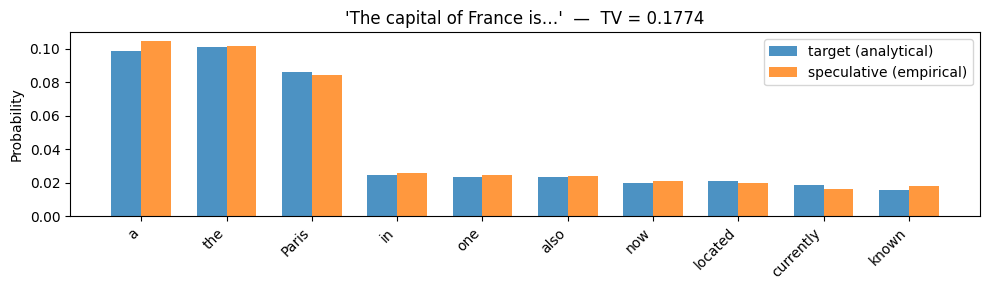

✓  'In machine learning, gradient descent'  TV distance = 0.0873


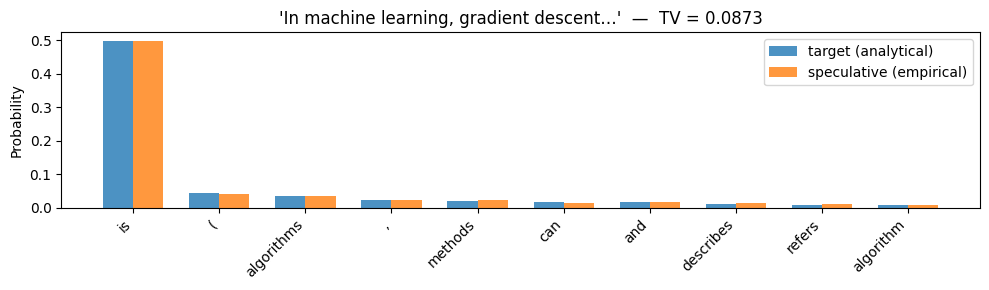


TV < 0.10 indicates distributions match (some sampling noise expected).


In [25]:
test_prompts_sampling = [
    "The capital of France is",
    "In machine learning, gradient descent",
]
temperature = 1.0
n_samples = 5000

print(f"Statistical verification  (T={temperature}, n={n_samples} spec samples, analytical target)\n")

for prompt in test_prompts_sampling:
    result = verify_sampling_distribution(
        draft_model, target_model, tokenizer,
        prompt, temperature=temperature, n_samples=n_samples,
    )
    tv = result["tv_distance"]
    status = "✓" if tv < 0.10 else "⚠"
    print(f"{status}  '{prompt[:45]}'  TV distance = {tv:.4f}")

    top = result["top_tokens"]
    labels = [tokenizer.decode([t]).strip() or f"[{t}]" for t in top]
    t_probs = [result["target_dist"][t].item() for t in top]
    s_probs = [result["spec_dist"][t].item() for t in top]

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.bar(x - width / 2, t_probs, width, label="target (analytical)", alpha=0.8)
    ax.bar(x + width / 2, s_probs, width, label="speculative (empirical)", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("Probability")
    ax.set_title(f"'{prompt[:40]}…'  —  TV = {tv:.4f}")
    ax.legend()
    plt.tight_layout()
    plt.show()

print("\nTV < 0.20 indicates distributions match (some sampling noise expected).")

### 3b — Speedup benchmark across k values

In [19]:
def benchmark(
    draft_model,
    target_model,
    tokenizer,
    prompt: str,
    k_values: list[int] = [1, 3, 5, 8, 10],
    max_new_tokens: int = 100,
    n_runs: int = 3,
) -> dict:
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
    results = {"baseline": []}

    # Baseline: pure target model
    for _ in range(n_runs):
        _, tps = greedy_decode(target_model, input_ids, max_new_tokens)
        results["baseline"].append(tps)
    results["baseline_median"] = float(np.median(results["baseline"]))

    # Speculative at each k
    results["speculative"] = {}
    for k in k_values:
        tps_runs, alpha_runs = [], []
        for _ in range(n_runs):
            _, stats = speculative_decode(draft_model, target_model, input_ids, k, max_new_tokens)
            tps_runs.append(stats.tokens_per_second)
            alpha_runs.append(stats.mean_acceptance_rate)
        results["speculative"][k] = {
            "tps_median": float(np.median(tps_runs)),
            "speedup":    float(np.median(tps_runs)) / results["baseline_median"],
            "mean_alpha": float(np.mean(alpha_runs)),
        }

    return results

In [20]:
bench_prompt = "In the field of artificial intelligence, large language models have"
bench_results = benchmark(draft_model, target_model, tokenizer, bench_prompt)

print(f"Baseline (target only): {bench_results['baseline_median']:.1f} tok/s\n")
print(f"{'k':>4}  {'tok/s':>8}  {'speedup':>8}  {'α':>10}")
print("-" * 38)
for k, v in bench_results["speculative"].items():
    print(f"{k:>4}  {v['tps_median']:>8.1f}  {v['speedup']:>8.2f}x  {v['mean_alpha']:>10.2%}")

Baseline (target only): 26.7 tok/s

   k     tok/s   speedup           α
--------------------------------------
   1      29.8      1.12x      72.41%
   3      37.4      1.40x      58.56%
   5      37.2      1.39x      48.00%
   8      30.2      1.13x      34.38%
  10      29.1      1.09x      30.00%


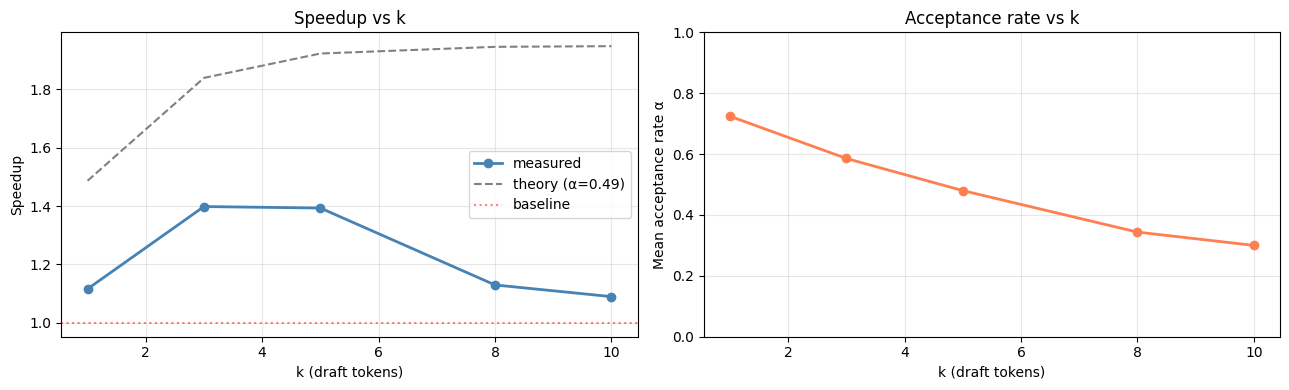

In [21]:
k_vals   = list(bench_results["speculative"].keys())
speedups = [bench_results["speculative"][k]["speedup"]    for k in k_vals]
alphas   = [bench_results["speculative"][k]["mean_alpha"] for k in k_vals]

# Theoretical speedup curve: E[tokens/pass] = (1 - α^(k+1)) / (1 - α)
# normalised by 1 (baseline) — gives expected speedup assuming target dominates runtime
def theoretical_speedup(k, alpha):
    if abs(1 - alpha) < 1e-9:
        return k + 1
    return (1 - alpha ** (k + 1)) / (1 - alpha)

mean_alpha = np.mean(alphas)
theory = [theoretical_speedup(k, mean_alpha) for k in k_vals]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(k_vals, speedups, "o-", color="steelblue", linewidth=2, label="measured")
ax1.plot(k_vals, theory,   "--", color="gray",      linewidth=1.5, label=f"theory (α={mean_alpha:.2f})")
ax1.axhline(1.0, linestyle=":", color="red", alpha=0.5, label="baseline")
ax1.set_xlabel("k (draft tokens)"); ax1.set_ylabel("Speedup")
ax1.set_title("Speedup vs k"); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(k_vals, alphas, "o-", color="coral", linewidth=2)
ax2.set_xlabel("k (draft tokens)"); ax2.set_ylabel("Mean acceptance rate α")
ax2.set_title("Acceptance rate vs k")
ax2.set_ylim(0, 1); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Note: measured speedup < theoretical because the draft model also has a cost.
# Theoretical assumes draft is free — valid when draft << target.

---
## Stage 4 — Code Edit Workload

Edit-style outputs contain large spans of unchanged code. The draft model
predicts these verbatim lines easily → acceptance rate α is much higher
than on open-ended generation → larger practical speedup.

In [22]:
edit_prompts = [
    """Complete this diff:
-    def forward(self, x):
-        return self.linear(x)
+    def forward(self, x: torch.Tensor) -> torch.Tensor:
+""",
    """Continue this Python function by adding type hints:
def compute_loss(predictions, targets, weights=None):
    # Add type annotations to this function
    def compute_loss(""",
]

open_ended_prompts = [
    "Explain the intuition behind attention mechanisms in transformers:",
    "Write a short story about a robot learning to paint:",
]

def measure_alpha_by_domain(prompts, label, k=5, max_new_tokens=60):
    alphas = []
    for prompt in prompts:
        ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
        _, stats = speculative_decode(draft_model, target_model, ids, k=k, max_new_tokens=max_new_tokens)
        alphas.append(stats.mean_acceptance_rate)
    print(f"{label}: mean α = {np.mean(alphas):.2%}  per prompt: {[f'{a:.0%}' for a in alphas]}")
    return alphas

edit_alphas      = measure_alpha_by_domain(edit_prompts,      "Edit-style ")
open_alphas      = measure_alpha_by_domain(open_ended_prompts, "Open-ended ")

Edit-style : mean α = 65.56%  per prompt: ['51%', '80%']
Open-ended : mean α = 53.78%  per prompt: ['32%', '75%']


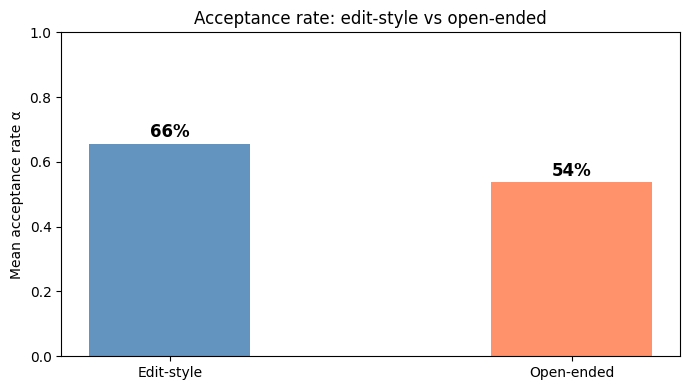

In [23]:
fig, ax = plt.subplots(figsize=(7, 4))
categories = ["Edit-style", "Open-ended"]
means  = [np.mean(edit_alphas), np.mean(open_alphas)]
colors = ["steelblue", "coral"]

bars = ax.bar(categories, means, color=colors, alpha=0.85, width=0.4)
ax.set_ylabel("Mean acceptance rate α")
ax.set_title("Acceptance rate: edit-style vs open-ended")
ax.set_ylim(0, 1)
for bar, v in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02,
            f"{v:.0%}", ha="center", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Appendix — Why the Math Works

The acceptance criterion `min(1, p_t / p_d)` comes directly from **rejection sampling**.

**Claim:** the distribution of each accepted token is exactly `p_target`.

**Proof sketch** for token `x`:

```
P(output = x) = P(x drawn from draft) × P(x accepted)
              + P(x drawn from correction)

             = p_d(x) × min(1, p_t(x)/p_d(x))
             + P(rejection at some earlier pos) × p_corrected(x)
```

The correction distribution `normalize(max(0, p_t - p_d))` handles exactly
the probability mass that `p_draft` under-allocated to `x` relative to `p_target`.
The two terms sum to `p_target(x)`. ∎

**Implication:** you get **exactly** target-model quality, not an approximation.
The only thing you trade is compute on the draft side.

---
## Extension Exercises

**1. ~~Temperature sampling~~ ✅ Implemented above**  
`draft_autoregressive`, `rejection_sample`, and `speculative_decode` all accept  
a `temperature` parameter. Greedy (T=0) and sampling (T>0) are both supported  
and statistically verified in Stage 3a-bis.

**2. Dynamic k**  
Track rolling acceptance rate. If `α > 0.8` → increase k. If `α < 0.5` → decrease k.  
Plot k over time for different prompt types.

**3. Tree speculative decoding**  
Instead of one draft sequence, generate a beam of width `b` with depth `d`.  
Target scores all `b×d` nodes in one pass using a tree attention mask.

**4. Medusa heads**  
Attach `k` extra linear heads to the draft model, each predicting token at offset `+i`.  
No separate draft model needed — all heads run in one forward pass.

**5. Code model pair**  
Swap in `codegen-350M` (draft) + `codegen-2B` (target).  
Repeat Stage 4 acceptance rate analysis with real code edit prompts.